In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [49]:
df1 = pd.read_csv('C:/3курс/DS/films/movies_metadata.csv')
#df2 = pd.read_csv('C:/3курс/DS/films/keywords.csv')

In [50]:
df11 = df1
df11 = df11.drop(['homepage', 'budget', 'status', 'overview', 'poster_path', 'original_title', 'production_companies', 'belongs_to_collection'], axis = 1)
df11['original_language'] = df11['original_language'].dropna().map({'en': 1}).fillna(0)
df11['adult'] = df11['adult'].dropna().map({'False': 0}).fillna(1)
df11['genres'] = df11['genres'].dropna().str.contains('Animation', case=False, na=False).astype(int)
df11['production_countries'] = df11['production_countries'].dropna().str.contains('US', case=False, na=False).astype(int)
df11 = df11.drop(['imdb_id', 'id', 'spoken_languages', 'tagline', 'video', 'title', 'popularity'], axis = 1)
df11['release_date'] = df11['release_date'].dropna().str[:4].astype(int)
df11 = df11[df11['release_date'].between(1800, 2100)]

In [51]:
df11

,adult,genres,original_language,production_countries,release_date,revenue,runtime,vote_average,vote_count
0,0.0,1,1.0,1.0,1995.0,373554033.0,81.0,7.7,5415.0
1,0.0,0,1.0,1.0,1995.0,262797249.0,104.0,6.9,2413.0
2,0.0,0,1.0,1.0,1995.0,0.0,101.0,6.5,92.0
3,0.0,0,1.0,1.0,1995.0,81452156.0,127.0,6.1,34.0
4,0.0,0,1.0,1.0,1995.0,76578911.0,106.0,5.7,173.0
...,...,...,...,...,...,...,...,...,...
45460,0.0,0,1.0,1.0,1991.0,0.0,104.0,5.7,26.0
45462,0.0,0,0.0,0.0,2011.0,0.0,360.0,9.0,3.0
45463,0.0,0,1.0,1.0,2003.0,0.0,90.0,3.8,6.0
45464,0.0,0,1.0,1.0,1917.0,0.0,87.0,0.0,0.0


In [52]:
df3 = df11

In [53]:
from sklearn.preprocessing import MinMaxScaler

X = df3.to_numpy()

scaler = MinMaxScaler(feature_range=(0, 1))
scaler_dataset = scaler.fit_transform(X)
X_scal = scaler_dataset
X_scal

array([[0.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        6.44904459e-02, 7.70000000e-01, 3.84724689e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        8.28025478e-02, 6.90000000e-01, 1.71438721e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        8.04140127e-02, 6.50000000e-01, 6.53641208e-03],
       ...,
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        7.16560510e-02, 3.80000000e-01, 4.26287744e-04],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        6.92675159e-02, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        5.97133758e-02, 0.00000000e+00, 0.00000000e+00]], shape=(45376, 9))

In [54]:
import ast

def extract_first_genre_simple(genre_str):
    try:
        if pd.isna(genre_str) or genre_str == '' or genre_str == '[]':
            return None
        
        # Преобразуем строку в список
        if isinstance(genre_str, str):
            genre_list = ast.literal_eval(genre_str)
        else:
            genre_list = genre_str
        
        # Проверяем наличие элементов и извлекаем первый жанр
        return genre_list[0]['name'] if genre_list and isinstance(genre_list[0], dict) else None
    except:
        return None

df11['genres_binary'] = df1['genres'].str.contains('Animation', case=False, na=False).astype(int)  # исходный бинарный
df11['genres_text'] = df1['genres'].apply(extract_first_genre_simple)  # текстовый для анализа

In [55]:
df11

,adult,genres,original_language,production_countries,release_date,revenue,runtime,vote_average,vote_count,genres_binary,genres_text
0,0.0,1,1.0,1.0,1995.0,373554033.0,81.0,7.7,5415.0,1,Animation
1,0.0,0,1.0,1.0,1995.0,262797249.0,104.0,6.9,2413.0,0,Adventure
2,0.0,0,1.0,1.0,1995.0,0.0,101.0,6.5,92.0,0,Romance
3,0.0,0,1.0,1.0,1995.0,81452156.0,127.0,6.1,34.0,0,Comedy
4,0.0,0,1.0,1.0,1995.0,76578911.0,106.0,5.7,173.0,0,Comedy
...,...,...,...,...,...,...,...,...,...,...,...
45460,0.0,0,1.0,1.0,1991.0,0.0,104.0,5.7,26.0,0,Drama
45462,0.0,0,0.0,0.0,2011.0,0.0,360.0,9.0,3.0,0,Drama
45463,0.0,0,1.0,1.0,2003.0,0.0,90.0,3.8,6.0,0,Action
45464,0.0,0,1.0,1.0,1917.0,0.0,87.0,0.0,0.0,0,None


In [56]:
df11['genres'].unique()

array([1, 0])

In [57]:
df1['overview'] 

0        Led by Woody, Andy's toys live happily in his ...
1        When siblings Judy and Peter discover an encha...
2        A family wedding reignites the ancient feud be...
3        Cheated on, mistreated and stepped on, the wom...
4        Just when George Banks has recovered from his ...
                               ...                        
45461          Rising and falling between a man and woman.
45462    An artist struggles to finish his work while a...
45463    When one of her hits goes wrong, a professiona...
45464    In a small town live two brothers, one a minis...
45465    50 years after decriminalisation of homosexual...
Name: overview, Length: 45466, dtype: object

In [58]:
df_for_cluster = df11.copy()

In [59]:
# уже закодированы
categorical_features = ['adult', 'original_language', 'production_countries']

numerical_features = ['release_date', 'revenue', 'runtime', 'vote_average', 'vote_count']

# Бинарный признак Animation
binary_features = ['genres_binary']

# Текстовый жанр для OneHotEncoding
df_for_cluster['genres_fill'] = df11['genres_text'].fillna('Unknown')



In [60]:
from sklearn.preprocessing import OneHotEncoder
genre_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
genre_encoded = genre_encoder.fit_transform(df_for_cluster[['genres_fill']])


In [61]:
scaler = MinMaxScaler()
numerical_scaled = scaler.fit_transform(df_for_cluster[numerical_features].fillna(0))

In [62]:
from scipy.sparse import hstack, csr_matrix

numerical_sparse = csr_matrix(numerical_scaled)
categorical_sparse = csr_matrix(df_for_cluster[categorical_features].fillna(0).values)
binary_sparse = csr_matrix(df_for_cluster[binary_features].fillna(0).values)
genre_sparse = csr_matrix(genre_encoded)

In [63]:
# Объединяем все признаки
X_final = hstack([numerical_sparse, categorical_sparse, binary_sparse, genre_sparse])

In [64]:
# Кластеризация
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
df11['cluster'] = kmeans.fit_predict(X_final)

In [65]:
print("Распределение по кластерам:")
print(df11['cluster'].value_counts().sort_index())


Распределение по кластерам:
cluster
0     3409
1     4061
2     4982
3     2581
4     5319
5     2384
6     2233
7     1067
8     3404
9     1248
10    1552
11    1474
12    4683
13    3693
14    3286
Name: count, dtype: int64


In [66]:
# Статистика по кластерам
cluster_stats = df11.groupby('cluster').agg({
    'vote_average': 'mean',
    'revenue': 'mean',
    'runtime': 'mean',
    'genres_text': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'None',
    'genres_binary': 'mean'  # доля анимации в кластере
}).round(2)

In [67]:
print(cluster_stats)

         vote_average      revenue  runtime  genres_text  genres_binary
cluster                                                                
0                5.43  34525768.99    98.48       Action           0.03
1                6.18    994206.87   104.15        Drama           0.00
2                5.61  14234002.37    91.97       Comedy           0.01
3                5.62   1321621.88   100.58        Drama           0.00
4                5.78  12236917.82   103.77        Drama           0.00
5                4.30     78255.70    70.24         None           0.00
6                5.92   1227637.44    90.09       Comedy           0.01
7                5.24    930594.89    88.00       Horror           0.00
8                5.81    306109.32    86.71  Documentary           0.00
9                5.24  12132884.36    94.04     Thriller           0.00
10               5.02  10370934.79    89.40       Horror           0.00
11               6.26  40002396.83    61.87    Animation        

In [68]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sil_score = silhouette_score(X_final, df11['cluster'])
print(f"Silhouette Score: {sil_score:.3f}")

Silhouette Score: 0.483


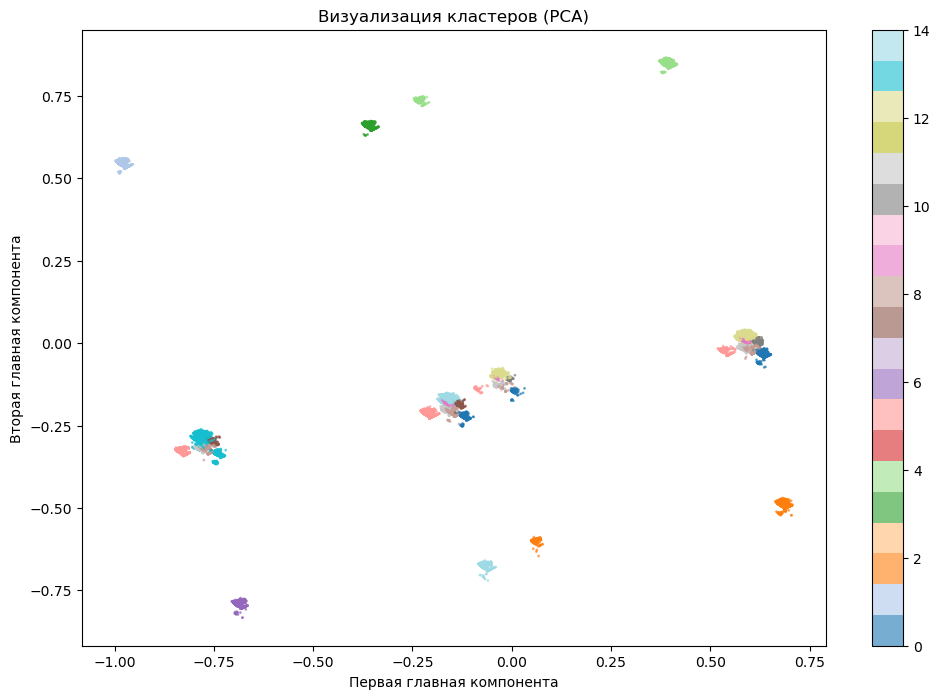

In [69]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final.toarray() if hasattr(X_final, 'toarray') else X_final)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df11['cluster'], cmap='tab20', s=1, alpha=0.6)
plt.colorbar(scatter)
plt.title('Визуализация кластеров (PCA)')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.show()

